In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [5]:
df = pd.read_csv(r"C:\Users\prana\OneDrive\Desktop\Nassau_Candy_Profitability_Analysis\datasets\nassau_candy_data.csv")

In [7]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [9]:
df.shape

(10194, 18)

In [11]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Country/Region', 'City', 'State/Province',
       'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name',
       'Sales', 'Units', 'Gross Profit', 'Cost'],
      dtype='object')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  object 
 7   City            10194 non-null  object 
 8   State/Province  10194 non-null  object 
 9   Postal Code     10194 non-null  object 
 10  Division        10194 non-null  object 
 11  Region          10194 non-null  object 
 12  Product ID      10194 non-null  object 
 13  Product Name    10194 non-null  object 
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null 

In [15]:
df.describe()

,Row ID,Customer ID,Sales,Units,Gross Profit,Cost
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,134468.961154,13.908537,3.791838,9.166451,4.742087
std,2942.898656,20231.483007,11.341020,2.228317,6.643740,5.061647
min,1.000000,100006.000000,1.250000,1.000000,0.250000,0.600000
25%,2549.250000,117212.000000,7.200000,2.000000,4.900000,2.400000
50%,5097.500000,133550.000000,10.800000,3.000000,7.470000,3.600000
75%,7645.750000,152051.000000,18.000000,5.000000,12.250000,5.700000
max,10194.000000,192314.000000,260.000000,14.000000,130.000000,130.000000


In [17]:
df["Profit_per_Unit"] = df["Gross Profit"] / df["Units"]

df["Profit_Margin_%"] = (df["Gross Profit"] / df["Sales"]) * 100

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Profit_per_Unit,Profit_Margin_%
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,2.11,64.923077
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,2.45,65.333333
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00,2.49,71.346705
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30,2.50,69.444444
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,2.45,65.333333


In [19]:
top_products = df.groupby("Product Name")["Gross Profit"].sum().sort_values(ascending=False)

top_products.head(10)

Product Name
Wonka Bar -Scrumdiddlyumptious       19357.50
Wonka Bar - Triple Dazzle Caramel    18610.20
Wonka Bar - Milk Chocolate           17443.37
Wonka Bar - Nutty Crunch Surprise    16819.95
Wonka Bar - Fudge Mallows            16593.60
Lickable Wallpaper                    3930.00
Wonka Gum                              310.70
Everlasting Gobstopper                 104.00
Kazookles                               92.75
Hair Toffee                             59.50
Name: Gross Profit, dtype: float64

In [21]:
region_sales = df.groupby("Region")["Sales"].sum()

region_sales

Region
Atlantic    41197.24
Gulf        22247.26
Interior    32037.60
Pacific     46301.53
Name: Sales, dtype: float64

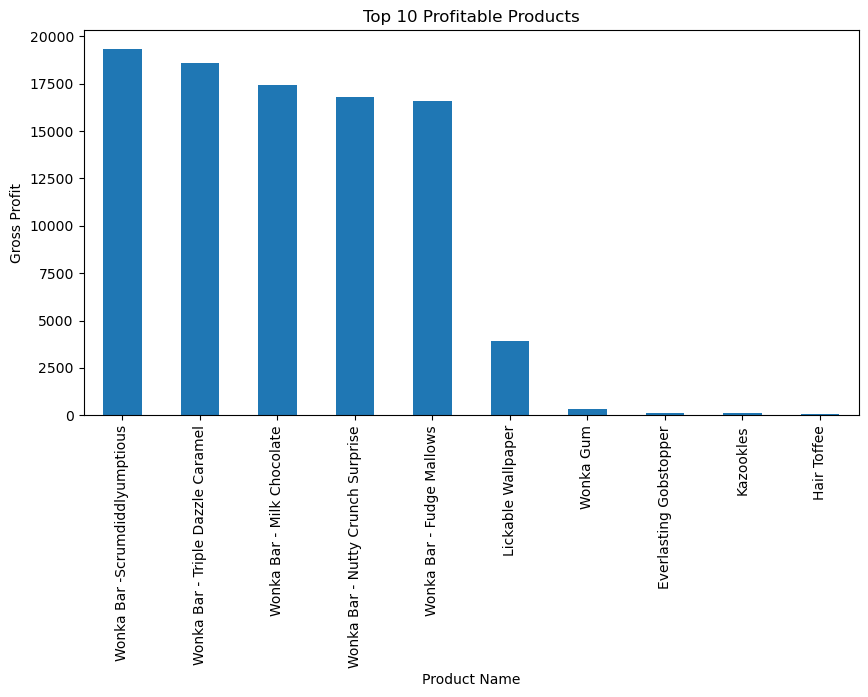

In [23]:
import matplotlib.pyplot as plt

top_products.head(10).plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Profitable Products")
plt.ylabel("Gross Profit")
plt.xlabel("Product Name")
plt.show()

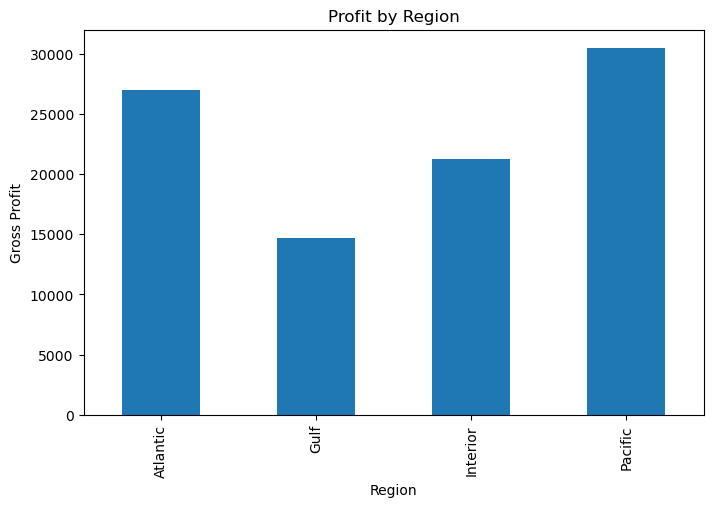

In [25]:
region_profit = df.groupby("Region")["Gross Profit"].sum()

region_profit.plot(kind="bar", figsize=(8,5))
plt.title("Profit by Region")
plt.ylabel("Gross Profit")
plt.show()

In [27]:
top_customers = df.groupby("Customer ID")["Sales"].sum().sort_values(ascending=False)

top_customers.head(10)

Customer ID
131807    454.40
115238    380.50
122336    352.20
164756    304.14
124163    247.35
164770    232.40
125388    216.00
163790    208.95
164147    204.65
140326    202.05
Name: Sales, dtype: float64

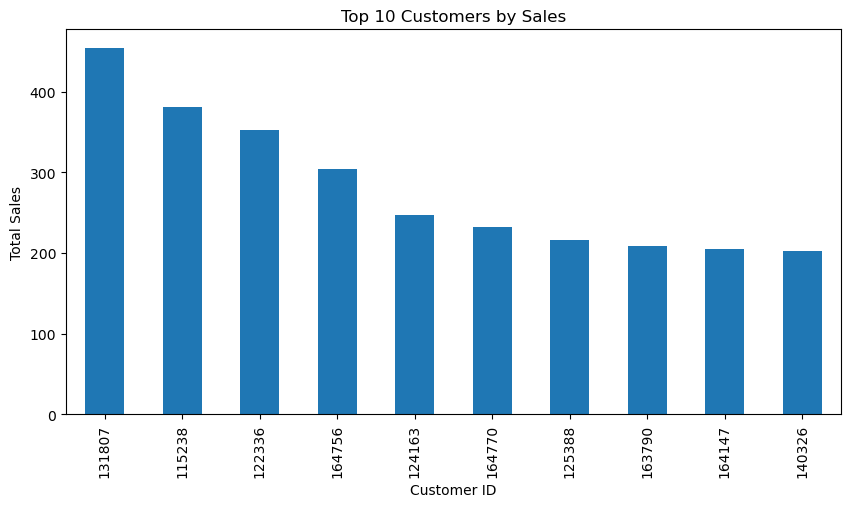

In [29]:
top_customers.head(10).plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Customers by Sales")
plt.ylabel("Total Sales")
plt.xlabel("Customer ID")
plt.show()

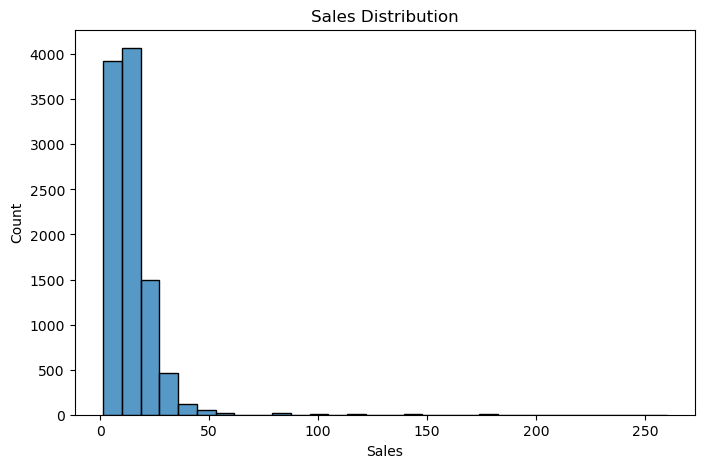

In [31]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df["Sales"], bins=30)
plt.title("Sales Distribution")
plt.show()

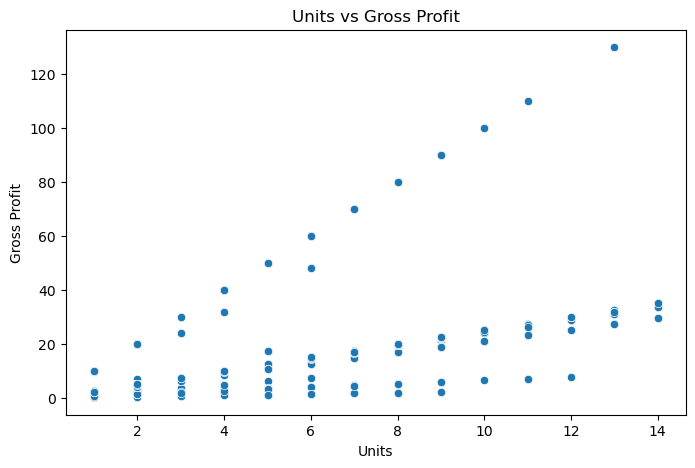

In [33]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Units", y="Gross Profit", data=df)
plt.title("Units vs Gross Profit")
plt.show()

In [35]:
df.corr(numeric_only=True)

,Row ID,Customer ID,Sales,Units,Gross Profit,Cost,Profit_per_Unit,Profit_Margin_%
Row ID,1.000000,-0.008749,0.005513,0.000502,0.008031,0.001812,0.023530,0.017730
Customer ID,-0.008749,1.000000,-0.005401,-0.011616,-0.005964,-0.004274,0.006425,0.012470
Sales,0.005513,-0.005401,1.000000,0.729347,0.976404,0.958986,0.573643,-0.111106
Units,0.000502,-0.011616,0.729347,1.000000,0.815820,0.563344,0.010298,-0.013689
Gross Profit,0.008031,-0.005964,0.976404,0.815820,1.000000,0.875144,0.509454,0.036781
Cost,0.001812,-0.004274,0.958986,0.563344,0.875144,1.000000,0.616602,-0.297219
Profit_per_Unit,0.023530,0.006425,0.573643,0.010298,0.509454,0.616602,1.000000,0.119464
Profit_Margin_%,0.017730,0.012470,-0.111106,-0.013689,0.036781,-0.297219,0.119464,1.000000


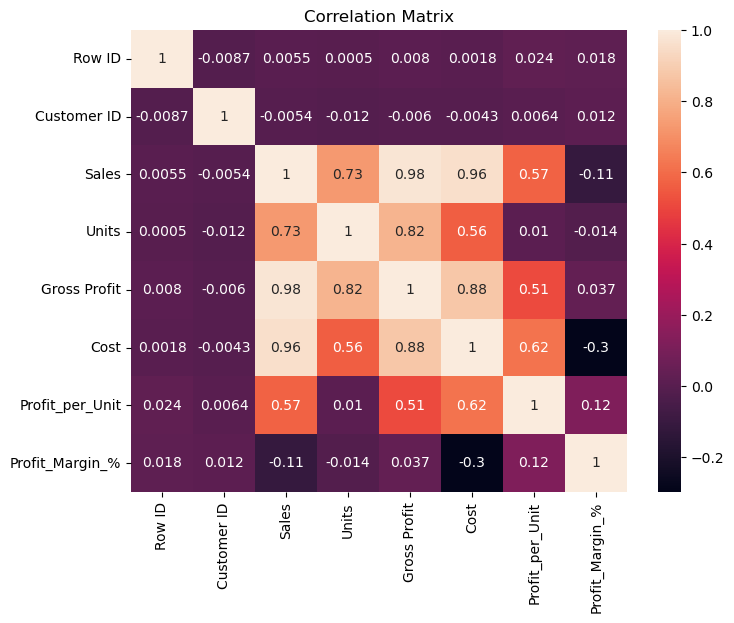

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

In [39]:
df.to_csv("clean_nassau_candy_data.csv", index=False)

In [43]:
df.to_csv(r"C:\Users\prana\OneDrive\Desktop\Nassau_Candy_Profitability_Analysis\datasets\clean_nassau_candy_data.csv", index=False)

In [45]:
df_clean = pd.read_csv(r"C:\Users\prana\OneDrive\Desktop\Nassau_Candy_Profitability_Analysis\datasets\clean_nassau_candy_data.csv")

df_clean.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Profit_per_Unit,Profit_Margin_%
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,2.11,64.923077
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,2.45,65.333333
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00,2.49,71.346705
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30,2.50,69.444444
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,2.45,65.333333


In [47]:
import os
os.getcwd()

'C:\\Users\\prana'